In [1]:
import pandas as pd
import torch
import numpy as np
import os
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

print("\n1. Mounting Google Drive...")
drive.mount('/content/drive')
print("Drive mounted")

model_path = '/content/drive/MyDrive/distilbert_toxicity_model_final'

if os.path.exists(model_path):
    print(f"✓ Model found at: {model_path}")
else:
    print(f"❌ Model not found at: {model_path}")
    print("   Checking alternative locations...")

    # Alternative: check if model is in current directory
    if os.path.exists('./distilbert_toxicity_model_final'):
        model_path = './distilbert_toxicity_model_final'
        print(f"✓ Model found locally at: {model_path}")
    else:
        print("   Please ensure model is saved in Drive")

print("\n2. Loading saved data...")

if os.path.exists('train_subset_cleaned.csv') and os.path.exists('eval_subset_cleaned.csv'):
    train_df = pd.read_csv('train_subset_cleaned.csv')
    eval_df = pd.read_csv('eval_subset_cleaned.csv')
    print("   Loaded from current directory")
else:
    train_df = pd.read_csv('/content/drive/MyDrive/train_subset_cleaned.csv')
    eval_df = pd.read_csv('/content/drive/MyDrive/eval_subset_cleaned.csv')
    print("   Loaded from Google Drive")

print(f"   Training set: {len(train_df):,} rows")
print(f"   Evaluation set: {len(eval_df):,} rows")
print(f"   Training toxic %: {train_df['toxic_binary'].mean():.2%}")
print(f"   Evaluation toxic %: {eval_df['toxic_binary'].mean():.2%}")

print("\n3. Loading saved model from Drive...")
model = DistilBertForSequenceClassification.from_pretrained(model_path)
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()
print(f"   Model loaded on {device}")
print(f"   Model parameters: {model.num_parameters():,}")

print("\n4. Verification:")
print(f"   Eval toxic %: {eval_df['toxic_binary'].mean():.2%}")
print(f"   Model device: {next(model.parameters()).device}")

print("\nSetup complete! Ready for analysis.")


1. Mounting Google Drive...
Mounted at /content/drive
Drive mounted
✓ Model found at: /content/drive/MyDrive/distilbert_toxicity_model_final

2. Loading saved data...
   Loaded from current directory
   Training set: 100,000 rows
   Evaluation set: 20,000 rows
   Training toxic %: 8.00%
   Evaluation toxic %: 8.00%

3. Loading saved model from Drive...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

   Model loaded on cuda
   Model parameters: 66,955,010

4. Verification:
   Eval toxic %: 8.00%
   Model device: cuda:0

Setup complete! Ready for analysis.


In [5]:
# Step 1: Construct identity cohorts
print("\n1. Constructing identity cohorts from evaluation set...")

eval_df['black'] = pd.to_numeric(eval_df['black'], errors='coerce').fillna(0)
eval_df['white'] = pd.to_numeric(eval_df['white'], errors='coerce').fillna(0)

high_black_df = eval_df[eval_df['black'] >= 0.5].copy()
print(f"\n   High-Black cohort: {len(high_black_df)} rows ({len(high_black_df)/len(eval_df)*100:.2f}% of eval set)")

reference_df = eval_df[(eval_df['black'] < 0.1) & (eval_df['white'] >= 0.5)].copy()
print(f"   Reference (White) cohort: {len(reference_df)} rows ({len(reference_df)/len(eval_df)*100:.2f}% of eval set)")

print("\n2. Cohort characteristics:")
print(f"\n   High-Black Cohort:")
print(f"   - Size: {len(high_black_df)}")
if len(high_black_df) > 0:
    print(f"   - Toxic comments: {high_black_df['toxic_binary'].sum()} ({high_black_df['toxic_binary'].mean():.2%})")
    print(f"   - Avg black score: {high_black_df['black'].mean():.3f}")

print(f"\n   Reference (White) Cohort:")
print(f"   - Size: {len(reference_df)}")
if len(reference_df) > 0:
    print(f"   - Toxic comments: {reference_df['toxic_binary'].sum()} ({reference_df['toxic_binary'].mean():.2%})")
    print(f"   - Avg white score: {reference_df['white'].mean():.3f}")


1. Constructing identity cohorts from evaluation set...

   High-Black cohort: 178 rows (0.89% of eval set)
   Reference (White) cohort: 200 rows (1.00% of eval set)

2. Cohort characteristics:

   High-Black Cohort:
   - Size: 178
   - Toxic comments: 48 (26.97%)
   - Avg black score: 0.848

   Reference (White) Cohort:
   - Size: 200
   - Toxic comments: 61 (30.50%)
   - Avg white score: 0.883


In [6]:
def get_cohort_predictions(df, model, tokenizer):
    if len(df) == 0:
        return np.array([]), np.array([]), np.array([])

    texts = df['comment_text'].tolist()
    inputs = tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        preds = (probs >= 0.6).astype(int)

    return preds, probs, df['toxic_binary'].values

print("\nGetting predictions for High-Black cohort...")
black_preds, black_probs, black_labels = get_cohort_predictions(high_black_df, model, tokenizer)

print("\nGetting predictions for Reference (White) cohort...")
ref_preds, ref_probs, ref_labels = get_cohort_predictions(reference_df, model, tokenizer)

print(f"\n   High-Black cohort: {len(black_preds)} predictions")
print(f"   Reference cohort: {len(ref_preds)} predictions")




Getting predictions for High-Black cohort...

Getting predictions for Reference (White) cohort...

   High-Black cohort: 178 predictions
   Reference cohort: 200 predictions


In [8]:
# Step 3: Compute fairness metrics
print("FAIRNESS METRICS BY COHORT")

def compute_cohort_metrics(labels, predictions):
    if len(labels) == 0:
        return None

    tn, fp, fn, tp = confusion_matrix(labels, predictions).ravel()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    positive_rate = predictions.mean()

    return {
        'TPR': tpr, 'FPR': fpr, 'FNR': fnr,
        'Precision': precision, 'Positive_Rate': positive_rate,
        'Size': len(labels), 'Toxic_Count': labels.sum()
    }

black_metrics = compute_cohort_metrics(black_labels, black_preds)
ref_metrics = compute_cohort_metrics(ref_labels, ref_preds)

print("\nCOHORT METRICS COMPARISON")
print("\n")
print(f"{'Metric':<20} {'High-Black Cohort':<25} {'Reference Cohort':<25}")


if black_metrics and ref_metrics:
    print(f"{'Size':<20} {black_metrics['Size']:<25} {ref_metrics['Size']:<25}")
    print(f"{'Toxic comments':<20} {black_metrics['Toxic_Count']:<25} {ref_metrics['Toxic_Count']:<25}")
    print(f"{'True Positive Rate (TPR)':<20} {black_metrics['TPR']:.4f} ({black_metrics['TPR']*100:.2f}%){'':<12} {ref_metrics['TPR']:.4f} ({ref_metrics['TPR']*100:.2f}%)")
    print(f"{'False Positive Rate (FPR)':<20} {black_metrics['FPR']:.4f} ({black_metrics['FPR']*100:.2f}%){'':<12} {ref_metrics['FPR']:.4f} ({ref_metrics['FPR']*100:.2f}%)")
    print(f"{'False Negative Rate (FNR)':<20} {black_metrics['FNR']:.4f} ({black_metrics['FNR']*100:.2f}%){'':<12} {ref_metrics['FNR']:.4f} ({ref_metrics['FNR']*100:.2f}%)")
    print(f"{'Precision':<20} {black_metrics['Precision']:.4f} ({black_metrics['Precision']*100:.2f}%){'':<12} {ref_metrics['Precision']:.4f} ({ref_metrics['Precision']*100:.2f}%)")
    print(f"{'Positive Prediction Rate':<20} {black_metrics['Positive_Rate']:.4f} ({black_metrics['Positive_Rate']*100:.2f}%){'':<12} {ref_metrics['Positive_Rate']:.4f} ({ref_metrics['Positive_Rate']*100:.2f}%)")

if ref_metrics and ref_metrics['FPR'] > 0:
    disparate_impact = black_metrics['FPR'] / ref_metrics['FPR']
    print(f"\nDISPARATE IMPACT RATIO (FPR_black / FPR_white): {disparate_impact:.3f}")
    if disparate_impact > 1:
        print(f"   Model flags Black-associated comments at {disparate_impact:.1f}x the rate of White-associated comments")

stat_parity_diff = black_metrics['Positive_Rate'] - ref_metrics['Positive_Rate']
print(f"\nSTATISTICAL PARITY DIFFERENCE: {stat_parity_diff:.4f}")

eq_opp_diff = black_metrics['TPR'] - ref_metrics['TPR']
print(f"\nEQUAL OPPORTUNITY DIFFERENCE (TPR difference): {eq_opp_diff:.4f}")


FAIRNESS METRICS BY COHORT

COHORT METRICS COMPARISON


Metric               High-Black Cohort         Reference Cohort         
Size                 178                       200                      
Toxic comments       48                        61                       
True Positive Rate (TPR) 0.4792 (47.92%)             0.6885 (68.85%)
False Positive Rate (FPR) 0.0923 (9.23%)             0.1007 (10.07%)
False Negative Rate (FNR) 0.5208 (52.08%)             0.3115 (31.15%)
Precision            0.6571 (65.71%)             0.7500 (75.00%)
Positive Prediction Rate 0.1966 (19.66%)             0.2800 (28.00%)

DISPARATE IMPACT RATIO (FPR_black / FPR_white): 0.916

STATISTICAL PARITY DIFFERENCE: -0.0834

EQUAL OPPORTUNITY DIFFERENCE (TPR difference): -0.2094


GENERATING VISUALIZATIONS


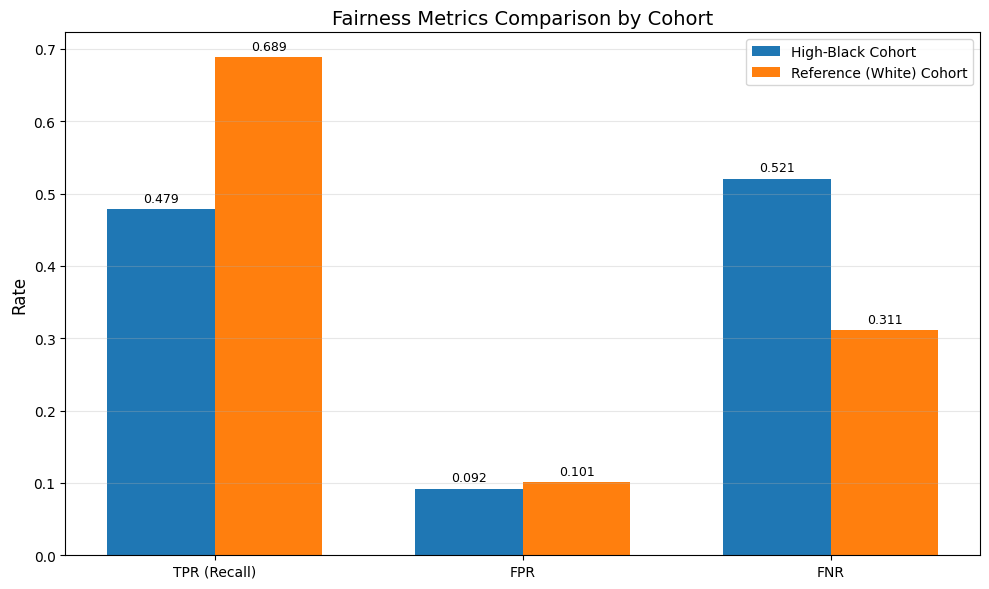

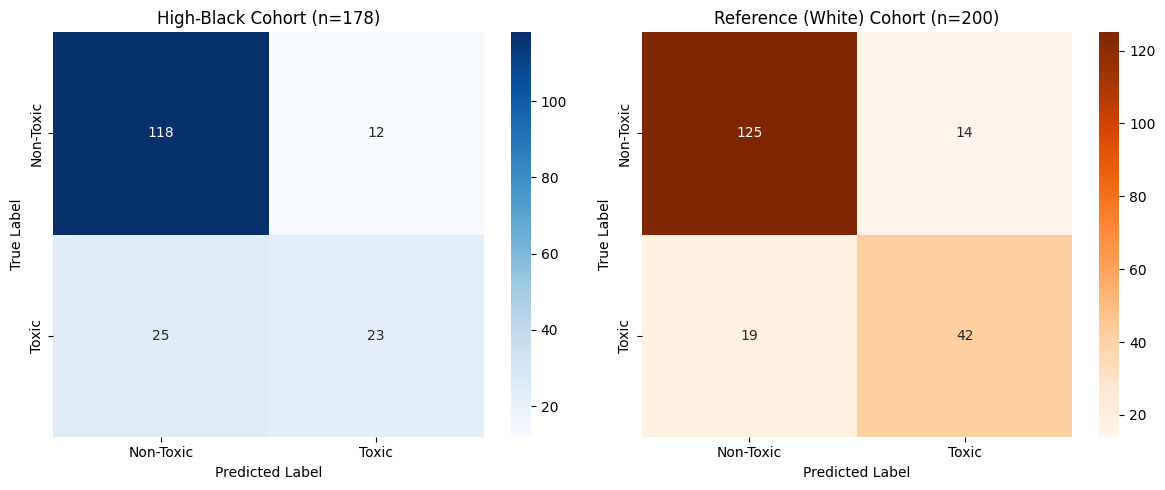

In [9]:
print("GENERATING VISUALIZATIONS")

fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['TPR (Recall)', 'FPR', 'FNR']
black_values = [black_metrics['TPR'], black_metrics['FPR'], black_metrics['FNR']]
ref_values = [ref_metrics['TPR'], ref_metrics['FPR'], ref_metrics['FNR']]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, black_values, width, label='High-Black Cohort', color='#1f77b4')
bars2 = ax.bar(x + width/2, ref_values, width, label='Reference (White) Cohort', color='#ff7f0e')

ax.set_ylabel('Rate', fontsize=12)
ax.set_title('Fairness Metrics Comparison by Cohort', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('fairness_metrics_comparison.png', dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_black = confusion_matrix(black_labels, black_preds)
sns.heatmap(cm_black, annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title(f'High-Black Cohort (n={len(black_labels)})', fontsize=12)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticklabels(['Non-Toxic', 'Toxic'])
axes[0].set_yticklabels(['Non-Toxic', 'Toxic'])

cm_ref = confusion_matrix(ref_labels, ref_preds)
sns.heatmap(cm_ref, annot=True, fmt='d', ax=axes[1], cmap='Oranges')
axes[1].set_title(f'Reference (White) Cohort (n={len(ref_labels)})', fontsize=12)
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_xticklabels(['Non-Toxic', 'Toxic'])
axes[1].set_yticklabels(['Non-Toxic', 'Toxic'])

plt.tight_layout()
plt.savefig('cohort_confusion_matrices.png', dpi=150)
plt.show()

In [10]:
print("KEY QUESTION: Which metric shows the largest disparity?")

disparities = {
    'False Positive Rate (FPR)': black_metrics['FPR'] - ref_metrics['FPR'],
    'False Negative Rate (FNR)': black_metrics['FNR'] - ref_metrics['FNR'],
    'True Positive Rate (TPR)': black_metrics['TPR'] - ref_metrics['TPR'],
    'Precision': black_metrics['Precision'] - ref_metrics['Precision'],
}

largest_metric = max(disparities, key=lambda k: abs(disparities[k]))
largest_diff = disparities[largest_metric]

print(f"\nDisparity Analysis:")
for metric, diff in disparities.items():
    direction = "higher" if diff > 0 else "lower"
    print(f"   • {metric}: {diff:+.4f} ({direction} for Black cohort)")

print(f"\nLARGEST DISPARITY: {largest_metric}")
print(f"   Difference: {largest_diff:+.4f}")


KEY QUESTION: Which metric shows the largest disparity?

Disparity Analysis:
   • False Positive Rate (FPR): -0.0084 (lower for Black cohort)
   • False Negative Rate (FNR): +0.2094 (higher for Black cohort)
   • True Positive Rate (TPR): -0.2094 (lower for Black cohort)
   • Precision: -0.0929 (lower for Black cohort)

LARGEST DISPARITY: False Negative Rate (FNR)
   Difference: +0.2094
